In [1]:
import os
import torch
import random
from PIL import Image
import torch.nn as nn
import seaborn as sns
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader

In [2]:
BATCH_SIZE = 10
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 50
LOSS_FACTOR_SELFSUPERVISED = 1

In [3]:
transform_super = transforms.Compose(
    [transforms.Resize(32),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, ), (0.5, ))])

In [4]:
class UnlabeledDataset(Dataset):    
    sesemi_transformations = {0: 0, 1: 90, 2: 180, 3: 270}    
    def __init__(self, folder_path):
        super().__init__()
        self.folder_path = folder_path
        self.image_names = os.listdir(folder_path)
        self.images_full_path_names = [f"{folder_path}/{i}" for i in self.image_names]    
    
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        img = Image.open(self.images_full_path_names[idx])
        # get a random sesemi transformation
        transformation_class_label = random.randint(0, len(self.sesemi_transformations)-1)
        # apply the randomly selected transformation
        angle = self.sesemi_transformations[transformation_class_label]
        data = transform_super(img)
        data = torchvision.transforms.functional.rotate(img=data, angle=angle)
        return data, transformation_class_label

In [5]:
folder_path = 'datasets/semi_supervised/unlabeled/'
unlabeled_ds = UnlabeledDataset(folder_path)

In [6]:
import torchvision

train_ds = torchvision.datasets.ImageFolder(root='datasets/semi_supervised/train', transform=transform_super)
test_ds = torchvision.datasets.ImageFolder(root='datasets/semi_supervised/test', transform=transform_super)

In [7]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [8]:
unlabeled_loader = DataLoader(unlabeled_ds, batch_size=BATCH_SIZE)

In [9]:
class SesemiNet(nn.Module):
    def __init__(self, n_super_classes, n_selfsuper_classes) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.fc1 = nn.Linear(16 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc_out_super = nn.Linear(64, n_super_classes)
        self.fc_out_selfsuper = nn.Linear(64, n_selfsuper_classes)
        self.relu = nn.ReLU()
        self.output_layer_super = nn.Sigmoid()
        self.output_layer_selfsuper = nn.LogSoftmax()
            
    def backbone(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        return x
    
    # TODO: update forward pass
    def forward(self, x_supervised, x_selfsupervised):
        x_supervised = self.backbone(x_supervised)
        x_supervised = self.fc_out_super(x_supervised)
        x_supervised = self.output_layer_super(x_supervised)
        
        x_selfsupervised = self.backbone(x_selfsupervised)
        x_selfsupervised = self.fc_out_selfsuper(x_selfsupervised)
        x_selfsupervised = self.output_layer_selfsuper(x_selfsupervised)
        return x_supervised, x_selfsupervised       

In [10]:
model = SesemiNet(n_super_classes=2, n_selfsuper_classes=4)
model.train()

SesemiNet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc_out_super): Linear(in_features=64, out_features=2, bias=True)
  (fc_out_selfsuper): Linear(in_features=64, out_features=4, bias=True)
  (relu): ReLU()
  (output_layer_super): Sigmoid()
  (output_layer_selfsuper): LogSoftmax(dim=None)
)

In [11]:
criterion_supervised = nn.CrossEntropyLoss()
criterion_selfsupervised = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
train_losses_self = []
for epoch in range(NUM_EPOCHS):
    train_loss = 0
    # TODO: get data
    data_loaders = zip(train_loader, unlabeled_loader)
    
    for i, (supervised_data, selfsupervised_data) in enumerate(data_loaders):
        X_super, y_super = supervised_data
        X_selfsuper, y_selfsuper = selfsupervised_data
        
        # init gradients
        optimizer.zero_grad()
        
        # forward pass
        y_super_pred, y_selfsuper_pred = model(X_super, X_selfsuper)
              
        # TODO: calc losses
        loss_super = criterion_supervised(y_super_pred, y_super)
        loss_selfsuper = criterion_selfsupervised(y_selfsuper_pred, y_selfsuper)
        loss = loss_super + loss_selfsuper * LOSS_FACTOR_SELFSUPERVISED
        
        # calculate gradients
        loss.backward()
         
        # update weights
        optimizer.step()
        
        # extract training losses
        train_loss += loss.item()
    train_losses_self.append(train_loss)
    print(f"Epoch {epoch}: Loss {train_loss}")

C:\Users\praveenchakra.bh\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\nn\modules\module.py:1773: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 0: Loss 4.178851842880249
Epoch 1: Loss 4.120718240737915
Epoch 2: Loss 4.072852373123169
Epoch 3: Loss 4.024655103683472
Epoch 4: Loss 3.9272143840789795
Epoch 5: Loss 3.805370330810547
Epoch 6: Loss 3.6649863719940186
Epoch 7: Loss 3.4398354291915894
Epoch 8: Loss 3.4345189332962036
Epoch 9: Loss 3.046841859817505
Epoch 10: Loss 2.9577927589416504
Epoch 11: Loss 2.6690640449523926
Epoch 12: Loss 2.5718090534210205
Epoch 13: Loss 2.2772706747055054
Epoch 14: Loss 1.9992468357086182
Epoch 15: Loss 1.6807587146759033
Epoch 16: Loss 1.8549901247024536
Epoch 17: Loss 1.6207494735717773
Epoch 18: Loss 1.5558024048805237
Epoch 19: Loss 1.5701069235801697
Epoch 20: Loss 1.5193973183631897
Epoch 21: Loss 1.4168724417686462
Epoch 22: Loss 1.3551629781723022
Epoch 23: Loss 1.342525601387024
Epoch 24: Loss 1.3499653339385986
Epoch 25: Loss 1.2928702235221863
Epoch 26: Loss 1.2725208401679993
Epoch 27: Loss 1.206257164478302
Epoch 28: Loss 1.2046570777893066
Epoch 29: Loss 1.145685434341430

<Axes: >

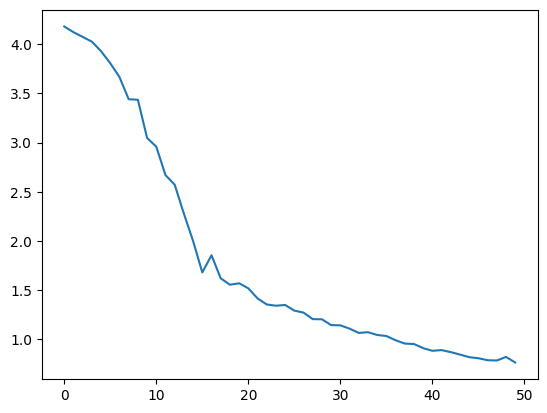

In [13]:
sns.lineplot(x=list(range(len(train_losses_self))), y=train_losses_self)

In [14]:
y_test_preds = []
y_test_trues = []
with torch.no_grad():
    for (X_test, y_test) in test_loader:
         y_test_pred = model(X_test, X_test) 
         y_test_pred_argmax = torch.argmax(y_test_pred[0], axis = 1)
         y_test_preds.extend(y_test_pred_argmax.numpy())
         y_test_trues.extend(y_test.numpy())

accuracy_score(y_pred=y_test_preds, y_true=y_test_trues)

C:\Users\praveenchakra.bh\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\nn\modules\module.py:1773: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


0.88